In [546]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from utils import *
from sklearn.preprocessing import StandardScaler
import importlib
import LogisticRegression as LogisticRegression
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import mlflow


In [547]:
# ============================================================
# MLflow Configuration
# ============================================================

mlflow.set_tracking_uri("http://localhost:5000")

mlflow.set_experiment("Car Price Classification")

2026/10/04 15:13:06 INFO mlflow.tracking.fluent: Experiment with name 'Car Price Classification' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1791101586219, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1791101586219, lifecycle_stage='active', name='Car Price Classification', tags={}, trace_location=None, workspace='default'>

In [548]:
#read the dataset
df = pd.read_csv("dataset/Cars.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [549]:
# Check for duplicates in the dataset
df.duplicated().sum()

np.int64(1202)

In [550]:
# View the duplicate rows to understand which entries are repeated and if they need to be addressed (e.g., by removing or consolidating them).
df[df.duplicated(keep=False)].sort_values(
    by=["name", "year"]
).head(20)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
1977,Audi Q3 2.0 TDI Quattro Premium Plus,2017,2825000,22000,Diesel,Dealer,Automatic,First Owner,15.73 kmpl,1968 CC,174.33 bhp,380Nm@ 1750-2500rpm,5.0
7324,Audi Q3 2.0 TDI Quattro Premium Plus,2017,2825000,22000,Diesel,Dealer,Automatic,First Owner,15.73 kmpl,1968 CC,174.33 bhp,380Nm@ 1750-2500rpm,5.0
2129,Audi Q5 3.0 TDI Quattro,2014,1850000,76131,Diesel,Individual,Automatic,First Owner,13.22 kmpl,2967 CC,241.4 bhp,580Nm@ 1400-3250rpm,5.0
7775,Audi Q5 3.0 TDI Quattro,2014,1850000,76131,Diesel,Individual,Automatic,First Owner,13.22 kmpl,2967 CC,241.4 bhp,580Nm@ 1400-3250rpm,5.0
131,Audi Q5 35TDI Premium Plus,2018,3975000,31800,Diesel,Dealer,Automatic,First Owner,17.01 kmpl,1968 CC,188 bhp,400nm@ 1750-3000rpm,5.0
1561,Audi Q5 35TDI Premium Plus,2018,3975000,31800,Diesel,Dealer,Automatic,First Owner,17.01 kmpl,1968 CC,188 bhp,400nm@ 1750-3000rpm,5.0
1857,Audi Q5 35TDI Premium Plus,2018,3975000,31800,Diesel,Dealer,Automatic,First Owner,17.01 kmpl,1968 CC,188 bhp,400nm@ 1750-3000rpm,5.0
3236,Audi Q5 35TDI Premium Plus,2018,3975000,31800,Diesel,Dealer,Automatic,First Owner,17.01 kmpl,1968 CC,188 bhp,400nm@ 1750-3000rpm,5.0
5245,Audi Q5 35TDI Premium Plus,2018,3975000,31800,Diesel,Dealer,Automatic,First Owner,17.01 kmpl,1968 CC,188 bhp,400nm@ 1750-3000rpm,5.0
7699,Audi Q5 35TDI Premium Plus,2018,3975000,31800,Diesel,Dealer,Automatic,First Owner,17.01 kmpl,1968 CC,188 bhp,400nm@ 1750-3000rpm,5.0


In [551]:
#Since they are completely identical, we can drop the duplicates to avoid biasing our model with repeated data points.
df = df.drop_duplicates()

In [552]:
# Check the distribution of the 'owner' column
df['owner'].value_counts()

owner
First Owner             4242
Second Owner            1974
Third Owner              536
Fourth & Above Owner     169
Test Drive Car             5
Name: count, dtype: int64

In [553]:
# Map the 'owner' column to numerical values
owner_mapping = {
    "First Owner": 1,
    "Second Owner": 2,
    "Third Owner": 3,
    "Fourth & Above Owner": 4,
    "Test Drive Car": 5
}

df["owner"] = df["owner"].map(owner_mapping)

In [554]:
#display the first few rows of the DataFrame to verify the changes
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,1,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,2,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,3,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,1,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,1,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [555]:
# Check the distribution of the 'owner' column to ensure the mapping was successful
df['owner'].value_counts()

owner
1    4242
2    1974
3     536
4     169
5       5
Name: count, dtype: int64

In [556]:
# Check the unique values in the 'fuel' column
df['fuel'].unique()

<ArrowStringArray>
['Diesel', 'Petrol', 'LPG', 'CNG']
Length: 4, dtype: str

In [557]:
# Remove rows with specific fuel types, as they use a different mileage system
remove_values = ["CNG", "LPG"]
df = df[~df["fuel"].isin(remove_values)]

In [558]:
# Check the unique values in the 'fuel' column after removing the specified fuel types
df['fuel'].unique()

<ArrowStringArray>
['Diesel', 'Petrol']
Length: 2, dtype: str

In [559]:
# Check the first few rows of the 'mileage' column and its data type
print(df["mileage"].head())
print(df["mileage"].dtype)

0     23.4 kmpl
1    21.14 kmpl
2     17.7 kmpl
3     23.0 kmpl
4     16.1 kmpl
Name: mileage, dtype: str
str


In [560]:
# Check for missing values in the 'mileage' column
df["mileage"].isna().sum()

np.int64(201)

In [561]:
# Display rows with missing values in the 'mileage' column
# do not handle the NaN value yet. just display the rows with NaN values in the mileage column to understand the data better.
df[df["mileage"].isnull()]

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
13,Maruti Swift 1.3 VXi,2007,200000,80000,Petrol,Individual,Manual,2,NaN,NaN,NaN,NaN,NaN
31,Fiat Palio 1.2 ELX,2003,70000,50000,Petrol,Individual,Manual,2,NaN,NaN,NaN,NaN,NaN
78,Tata Indica DLS,2003,50000,70000,Diesel,Individual,Manual,1,NaN,NaN,NaN,NaN,NaN
87,Maruti Swift VDI BSIV W ABS,2015,475000,78000,Diesel,Dealer,Manual,1,NaN,NaN,NaN,NaN,NaN
119,Maruti Swift VDI BSIV,2010,300000,120000,Diesel,Individual,Manual,2,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7740,Hyundai Santro Xing XG,2004,70000,70000,Petrol,Individual,Manual,2,NaN,NaN,NaN,NaN,NaN
7996,Hyundai Santro LS zipPlus,2000,140000,50000,Petrol,Individual,Manual,2,NaN,NaN,NaN,NaN,NaN
8009,Hyundai Santro Xing XS eRLX Euro III,2006,145000,80000,Petrol,Individual,Manual,2,NaN,NaN,NaN,NaN,NaN
8068,Ford Figo Aspire Facelift,2017,580000,165000,Diesel,Individual,Manual,1,NaN,NaN,NaN,NaN,NaN


In [562]:
# Check the shape of the DataFrame
df.shape

(6832, 13)

In [563]:
# Convert the 'mileage' column to float by extracting the numeric part and converting it to float
df["mileage"] = df.mileage.str.split().str[0].astype(float)

In [564]:
# Check the first few rows of the 'mileage' column and its data type to see if the conversion was successful
print(df["mileage"].head())
print(df["mileage"].dtype)

0    23.40
1    21.14
2    17.70
3    23.00
4    16.10
Name: mileage, dtype: float64
float64


In [565]:
# Convert the 'engine' column to float by extracting the numeric part and converting it to float
df["engine"] = df.engine.str.split().str[0].astype(float)

In [566]:
# Check the first few rows of the 'engine' column and its data type to see if the conversion was successful
print(df["engine"].head())
print(df["engine"].dtype)

0    1248.0
1    1498.0
2    1497.0
3    1396.0
4    1298.0
Name: engine, dtype: float64
float64


In [567]:
# Convert the 'max_power' column to float by extracting the numeric part and converting it to float
df["max_power"] = df["max_power"].str.split().str[0].astype(float)

In [568]:
#  Check the first few rows of the 'max_power' column and its data type to see if the conversion was successful
print(df["max_power"].head())
print(df["max_power"].dtype)

0     74.00
1    103.52
2     78.00
3     90.00
4     88.20
Name: max_power, dtype: float64
float64


In [569]:
# Check the first few rows of the 'name' column and its data type

print(df["name"].head())
print(df["name"].dtype)

0          Maruti Swift Dzire VDI
1    Skoda Rapid 1.5 TDI Ambition
2        Honda City 2017-2020 EXi
3       Hyundai i20 Sportz Diesel
4          Maruti Swift VXI BSIII
Name: name, dtype: str
str


In [570]:
# Split the 'name' column to extract the first word (brand name) and assign it back to the 'name' column
df["name"] = df["name"].str.split().str[0]

In [571]:
# Check the first few rows of the 'name' column and its data type to see if the conversion was successful
print(df["name"].head())
print(df["name"].dtype)

0     Maruti
1      Skoda
2      Honda
3    Hyundai
4     Maruti
Name: name, dtype: object
object


In [572]:
# Drop the 'torque' column from the DataFrame, as it may not be relevant for the analysis or model training
df = df.drop("torque", axis=1)

In [573]:
# Check the columns of the DataFrame to verify the changes
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats'],
      dtype='str')

In [574]:
# Remove rows where the 'owner' column has a value of 5 (Test Drive Car), as they are ridiculously expensive
df = df[df["owner"] != 5]

In [575]:
# Check the distribution of the 'owner' column after removing the rows with 'Test Drive Car' to ensure the changes were successful
df['owner'].value_counts()

owner
1    4191
2    1943
3     528
4     165
Name: count, dtype: int64

In [576]:
# Check for any remaining missing values in the DataFrame
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          201
engine           201
max_power        198
seats            201
dtype: int64

In [577]:
# Check the shape of the DataFrame after all the preprocessing steps
df.shape

(6827, 12)

In [578]:
#There are 8,028 rows (samples) and 12 columns (features + target)
#We have 214 rows with missing values in some columns, which is only about 2.7% of the dataset. 
# I think it is reasonable to remove these rows since we would still retain about 97.3% of the data.
df = df.dropna()

In [579]:
#check if there are any missing values left
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
dtype: int64

In [580]:
# Display the selling price column from the dataframe
df["selling_price"]

0       450000
1       370000
2       158000
3       225000
4       130000
         ...  
8121    260000
8122    475000
8123    320000
8124    135000
8125    382000
Name: selling_price, Length: 6626, dtype: int64

In [581]:
# Make a copy of the selling price column to preserve the original values
df["original_price"] = df["selling_price"].copy()

# Define the bins for categorizing the selling price
bins = [0, 250000, 500000, 1000000, np.inf]

# Categorize the selling price into bins
df["selling_price"] = pd.cut(
    df["original_price"],
    bins=bins,
    labels=[0, 1, 2, 3],
    include_lowest=True
).astype(int)

In [582]:
# Display the value counts of the categorized selling price
df["selling_price"].value_counts().sort_index()

selling_price
0    1705
1    2305
2    2147
3     469
Name: count, dtype: int64

In [583]:

# Display the summary statistics of the original selling price
print(df["original_price"].describe())

count    6.626000e+03
mean     5.267331e+05
std      5.116099e+05
min      2.999900e+04
25%      2.500000e+05
50%      4.220000e+05
75%      6.500000e+05
max      1.000000e+07
Name: original_price, dtype: float64


In [584]:
# Display the price range of each bin
df.groupby("selling_price").agg(
    min_price=("original_price", "min"),
    max_price=("original_price", "max"),
    count=("original_price", "count")
)

,min_price,max_price,count
selling_price,,,
0,29999,250000,1705
1,250999,500000,2305
2,501000,1000000,2147
3,1019999,10000000,469


In [585]:
# Display the column names of the dataframe
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats',
       'original_price'],
      dtype='str')

In [586]:
# Define the feature columns and target variable for the model
feature_columns = [
    "name",
    "year",
    "km_driven",
    "fuel",
    "seller_type",
    "transmission",
    "owner",
    "mileage",
    "engine",
    "max_power",
    "seats"
]

# Split the data into features (X) and target variable (y)
X = df[feature_columns]
y = df['selling_price']



In [587]:

# Display the value counts of the selling price
print(df["selling_price"].value_counts().sort_index())


selling_price
0    1705
1    2305
2    2147
3     469
Name: count, dtype: int64


In [588]:
#Split the dataset into training and testing sets, with 80% of the data used for training and 20% for testing. The random_state parameter is set to 42 to ensure reproducibility of the results.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,  stratify=y
)

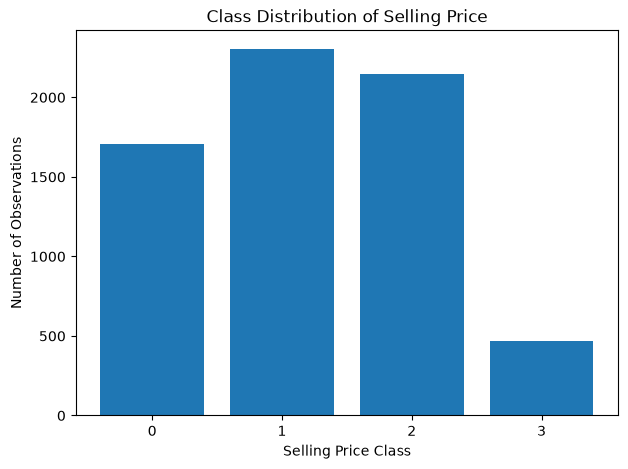

In [589]:
# Plot the class distribution of the selling price
class_counts = df["selling_price"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(class_counts.index, class_counts.values)

plt.xlabel("Selling Price Class")
plt.ylabel("Number of Observations")
plt.title("Class Distribution of Selling Price")

plt.xticks([0, 1, 2, 3])
plt.show()

In [590]:
# Check the first few rows of the training set to ensure that the split was successful and the data looks as expected
X_train.head()

,name,year,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
1041,Honda,2016,100000,Diesel,Individual,Manual,2,24.20,1498.0,98.60,7.0
7224,Toyota,2009,220000,Diesel,Individual,Manual,1,12.80,2494.0,102.00,8.0
1983,Maruti,2019,4875,Petrol,Dealer,Manual,1,21.63,998.0,67.04,5.0
7424,Maruti,2012,112048,Petrol,Individual,Manual,2,17.50,1298.0,85.80,5.0
158,Mercedes-Benz,2017,16000,Petrol,Dealer,Automatic,1,14.74,1991.0,181.04,5.0


In [591]:
# Define the categorical features that need to be one-hot encoded
categorical_features = [
    "name",
    "fuel",
    "seller_type",
    "transmission"
]

# Create a ColumnTransformer to apply one-hot encoding to the categorical features while leaving the other features unchanged
# It is needed since the model cannot handle categorical features directly, and one-hot encoding is a common technique to convert categorical variables into a format that can be provided to machine learning algorithms to do a better job in prediction.
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)
# FIT the preprocessor on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Only TRANSFORM test data
X_test_processed = preprocessor.transform(X_test)

In [592]:
# Reload the LogisticRegression module to ensure the latest changes are applied
LogisticRegression = importlib.reload(LogisticRegression)

In [593]:
# Standardize the processed training and test data
X_train_processed = X_train_processed.toarray()
X_test_processed = X_test_processed.toarray()
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)


In [594]:
# make sure our y is in the shape of (m, k)
# we will convert our output vector in 
# matrix where no. of columns is equal to the no. of classes. 
# The values in the matrix will be 0 or 1. For instance the rows 
# where we have output 2 the column 2 will contain 1 and the rest are all 0.
# in simple words, y will be of shape (m, k)
k = len(set(y))  # no. of class  (can also use np.unique)
m = X_train_scaled.shape[0]  # no.of samples
n = X_train_scaled.shape[1]  # no. of features
Y_train_encoded = np.zeros((m, k))
for each_class in range(k):
    cond = y_train==each_class
    Y_train_encoded[np.where(cond), each_class] = 1

In [595]:
# ----- Task 1: ordinary multinomial logistic regression -----
# Train and evaluate an ordinary multinomial logistic regression model for car price classification
with mlflow.start_run(run_name="Ordinary Multinomial Logistic Regression"):

    model = LogisticRegression.LogisticRegression(
        k=k,
        n=X_train_scaled.shape[1],
        method="minibatch",
        alpha=0.001,
        max_iter=5000,
        use_ridge=False
    )

    # Train the model
    model.fit(X_train_scaled, Y_train_encoded)

    # Make predictions
    yhat = model.predict(X_test_scaled)

    # Calculate metrics
    accuracy = model.accuracy(y_test, yhat)
    macro_precision = model.macro_precision(y_test, yhat)
    macro_recall = model.macro_recall(y_test, yhat)
    macro_f1 = model.macro_f1(y_test, yhat)

    weighted_precision = model.weighted_precision_standard(
        y_test, yhat
    )
    weighted_recall = model.weighted_recall_standard(
        y_test, yhat
    )
    weighted_f1 = model.weighted_f1_standard(
        y_test, yhat
    )

    # -----------------------------
    # Log parameters
    # -----------------------------

    mlflow.log_param("model", "Multinomial Logistic Regression")
    mlflow.log_param("method", "minibatch")
    mlflow.log_param("alpha", 0.001)
    mlflow.log_param("max_iter", 5000)
    mlflow.log_param("use_ridge", False)
    mlflow.log_param("test_size", 0.2)
    mlflow.log_param("random_state", 42)

    # -----------------------------
    # Log metrics
    # -----------------------------

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("macro_precision", macro_precision)
    mlflow.log_metric("macro_recall", macro_recall)
    mlflow.log_metric("macro_f1", macro_f1)
    mlflow.log_metric("weighted_precision", weighted_precision)
    mlflow.log_metric("weighted_recall", weighted_recall)
    mlflow.log_metric("weighted_f1", weighted_f1)

    # -----------------------------
    # Save model files
    # -----------------------------

    save(
        "models/car_price_classification_model.pkl",
        model
    )

    save(
        "models/car_price_classification_preprocessor.pkl",
        preprocessor
    )

    save(
        "models/car_price_classification_scaler.pkl",
        scaler
    )

    # Log the model files as MLflow artifacts
    mlflow.log_artifact(
        "models/car_price_classification_model.pkl"
    )

    mlflow.log_artifact(
        "models/car_price_classification_preprocessor.pkl"
    )

    mlflow.log_artifact(
        "models/car_price_classification_scaler.pkl"
    )

    print("===== Ordinary Logistic Regression =====")
    print("Accuracy:", accuracy)
    print("Macro Precision:", macro_precision)
    print("Macro Recall:", macro_recall)
    print("Macro F1:", macro_f1)
    print("Weighted Precision:", weighted_precision)
    print("Weighted Recall:", weighted_recall)
    print("Weighted F1:", weighted_f1)

Loss at iteration 0: 1.386371
Loss at iteration 500: 1.217377
Loss at iteration 1000: 1.142498
Loss at iteration 1500: 1.077929
Loss at iteration 2000: 1.057411
Loss at iteration 2500: 1.006842
Loss at iteration 3000: 0.986251
Loss at iteration 3500: 0.968685
Loss at iteration 4000: 0.952316
Loss at iteration 4500: 0.926806
Time taken: 13.86 seconds
===== Ordinary Logistic Regression =====
Accuracy: 0.6440422322775264
Macro Precision: 0.618938685398808
Macro Recall: 0.6639048521009485
Macro F1: 0.6039776135375647
Weighted Precision: 0.6749964765918092
Weighted Recall: 0.6440422322775264
Weighted F1: 0.6172465700122737
🏃 View run Ordinary Multinomial Logistic Regression at: http://localhost:5000/#/experiments/1/runs/db6cb454912343ab9fee93ec8c0cc028
🧪 View experiment at: http://localhost:5000/#/experiments/1


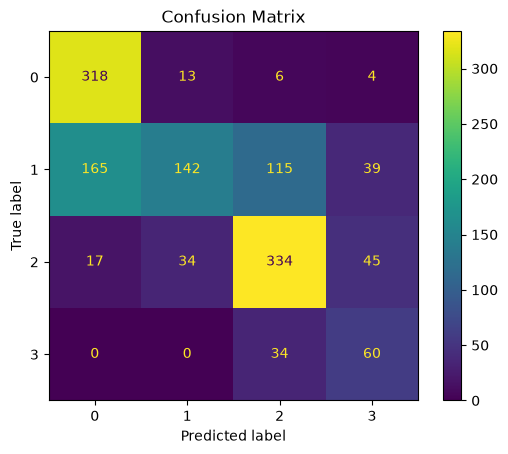

In [596]:
# Generate and display the confusion matrix for the test predictions
cm = confusion_matrix(y_test, yhat)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1, 2, 3]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [597]:
# ----- Task 2: Ridge / L2-regularized multinomial logistic regression -----
# Generate and display the confusion matrix for the ridge model predictions

with mlflow.start_run(run_name="Ridge Multinomial Logistic Regression"):

    ridge_model = LogisticRegression.LogisticRegression(
        k=k,
        n=X_train_scaled.shape[1],
        method="minibatch",
        alpha=0.001,
        max_iter=5000,
        use_ridge=True,
        lambda_=0.1
    )

    # Train the Ridge model
    ridge_model.fit(
        X_train_scaled,
        Y_train_encoded
    )

    # Predictions
    ridge_yhat = ridge_model.predict(
        X_test_scaled
    )

    # Calculate metrics
    ridge_accuracy = ridge_model.accuracy(
        y_test, ridge_yhat
    )

    ridge_macro_precision = ridge_model.macro_precision(
        y_test, ridge_yhat
    )

    ridge_macro_recall = ridge_model.macro_recall(
        y_test, ridge_yhat
    )

    ridge_macro_f1 = ridge_model.macro_f1(
        y_test, ridge_yhat
    )

    ridge_weighted_precision = (
        ridge_model.weighted_precision_standard(
            y_test, ridge_yhat
        )
    )

    ridge_weighted_recall = (
        ridge_model.weighted_recall_standard(
            y_test, ridge_yhat
        )
    )

    ridge_weighted_f1 = (
        ridge_model.weighted_f1_standard(
            y_test, ridge_yhat
        )
    )

    # -----------------------------
    # Log parameters
    # -----------------------------

    mlflow.log_param(
        "model",
        "Ridge Multinomial Logistic Regression"
    )

    mlflow.log_param("method", "minibatch")
    mlflow.log_param("alpha", 0.001)
    mlflow.log_param("max_iter", 5000)
    mlflow.log_param("use_ridge", True)
    mlflow.log_param("lambda", 0.1)
    mlflow.log_param("test_size", 0.2)
    mlflow.log_param("random_state", 42)

    # -----------------------------
    # Log metrics
    # -----------------------------

    mlflow.log_metric("accuracy", ridge_accuracy)
    mlflow.log_metric(
        "macro_precision",
        ridge_macro_precision
    )
    mlflow.log_metric(
        "macro_recall",
        ridge_macro_recall
    )
    mlflow.log_metric(
        "macro_f1",
        ridge_macro_f1
    )
    mlflow.log_metric(
        "weighted_precision",
        ridge_weighted_precision
    )
    mlflow.log_metric(
        "weighted_recall",
        ridge_weighted_recall
    )
    mlflow.log_metric(
        "weighted_f1",
        ridge_weighted_f1
    )

    # Save Ridge model
    save(
        "models/car_price_classification_ridge_model.pkl",
        ridge_model
    )

    # Log Ridge model
    mlflow.log_artifact(
        "models/car_price_classification_ridge_model.pkl"
    )

    print("===== Ridge Logistic Regression =====")
    print("Accuracy:", ridge_accuracy)
    print("Macro Precision:", ridge_macro_precision)
    print("Macro Recall:", ridge_macro_recall)
    print("Macro F1:", ridge_macro_f1)
    print("Weighted Precision:", ridge_weighted_precision)
    print("Weighted Recall:", ridge_weighted_recall)
    print("Weighted F1:", ridge_weighted_f1)

Loss at iteration 0: 1.389226
Loss at iteration 500: 1.235302
Loss at iteration 1000: 1.161492
Loss at iteration 1500: 1.145026
Loss at iteration 2000: 1.117852
Loss at iteration 2500: 1.120549
Loss at iteration 3000: 1.109106
Loss at iteration 3500: 1.091655
Loss at iteration 4000: 1.103590
Loss at iteration 4500: 1.094732
Time taken: 7.06 seconds
===== Ridge Logistic Regression =====
Accuracy: 0.6312217194570136
Macro Precision: 0.6055047223230131
Macro Recall: 0.6604511485264419
Macro F1: 0.5931095672216865
Weighted Precision: 0.6625145997222611
Weighted Recall: 0.6312217194570136
Weighted F1: 0.6047644091897786
🏃 View run Ridge Multinomial Logistic Regression at: http://localhost:5000/#/experiments/1/runs/7c2adf1d567f4582868be3c1522ee0eb
🧪 View experiment at: http://localhost:5000/#/experiments/1


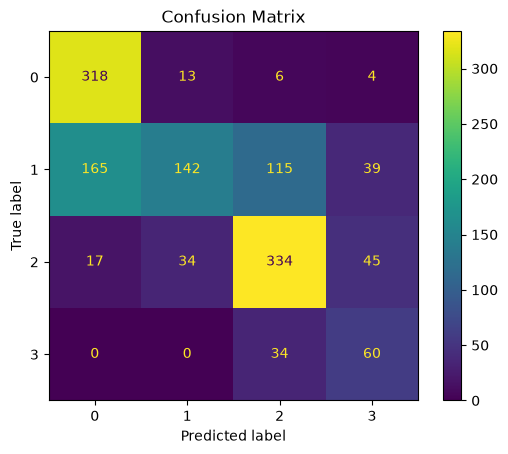

In [598]:

# Generate and display the confusion matrix for the ordinary multinomial logistic regression model predictions
cm = confusion_matrix(y_test, yhat)
# Compute the confusion matrix for the ordinary multinomial logistic regression model predictions
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1, 2, 3]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

The standard Multinomial Logistic Regression model achieved an accuracy of 64.33%, a macro F1-score of 60.19%, and a weighted F1-score of 61.76%. In comparison, the Ridge Logistic Regression model with λ = 0.1 achieved an accuracy of 63.12%, a macro F1-score of 59.32%, and a weighted F1-score of 60.58%. These results indicate that the standard Logistic Regression model provided slightly better overall classification performance than the Ridge-regularized model under the current experimental conditions.

The macro recall values of the two models were very similar, with 66.10% for the standard model and 66.04% for the Ridge model. Although the Ridge Logistic Regression model achieved a higher recall for Class 3 (66.67% compared to 62.77%), its recall for Class 1 and Class 2 was slightly lower than that of the standard model. Consequently, the inclusion of Ridge regularization with λ = 0.1 did not lead to improvements in overall accuracy, macro F1-score, weighted F1-score, or macro recall. Therefore, the standard Multinomial Logistic Regression model remains the preferred choice for this dataset and experimental setup.